# Spotify Music Recommendation System
## Notebook 04 — Feature Engineering

**Purpose:** Transform cleaned audio features into a normalised 14-dimensional vector for cosine-similarity-based recommendation.

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Load Cleaned Data](#2-load-cleaned-data)
3. [Feature Plan](#3-feature-plan)
4. [Step 1 — Log-Transform Skewed Features](#4-step-1--log-transform-skewed-features)
5. [Step 2 — Scale All Features to 0–1](#5-step-2--scale-all-features-to-01)
6. [Step 3 — Cyclic Encoding for Key](#6-step-3--cyclic-encoding-for-key)
7. [Step 4 — Binary Features](#7-step-4--binary-features)
8. [Assemble Feature Matrix](#8-assemble-feature-matrix)
9. [Save Outputs](#9-save-outputs)
10. [Summary](#10-summary)

## 1. Setup & Imports

In [12]:
import sys
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path('..').resolve()))

from src.data.load import load_clean
from src.features.build_features import build_feature_matrix, FEATURE_COLUMNS

OUTPUT_DIR = Path('../data/processed')
print('src modules loaded.')
print('FEATURE_COLUMNS:', FEATURE_COLUMNS)

src modules loaded.
FEATURE_COLUMNS: ['valence', 'acousticness', 'danceability', 'energy', 'loudness', 'log_instrumentalness', 'log_speechiness', 'log_liveness', 'tempo_norm', 'key_sin', 'key_cos', 'mode', 'explicit_int', 'popularity_norm']


## 2. Load Cleaned Data

In [13]:
df = load_clean()   # from src.data.load

print(f'Loaded: {df.shape[0]:,} tracks, {df.shape[1]} columns')
df[['id', 'name', 'artists_clean', 'year', 'popularity', 'energy', 'valence']].head(3)

Loaded: 169,040 tracks, 27 columns


,id,name,artists_clean,year,popularity,energy,valence
0,4BJqT0PrAfrxzMOxytFOIz,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...","Sergei Rachmaninoff, James Levine, Berliner Ph...",1921,4,0.211,0.0594
1,7xPhfUan2yNtyFG0cUWkt8,Clancy Lowered the Boom,Dennis Day,1921,5,0.341,0.9630
2,1o6I8BglA6ylDMrIELygv1,Gati Bali,KHP Kridhamardawa Karaton Ngayogyakarta Hadini...,1921,5,0.166,0.0394


## 3. Feature Plan

We use **14 features** for the recommendation engine:

| Feature | Raw Column | Transform | Why |
|---|---|---|---|
| valence | `valence` | MinMax | Already 0–1 |
| acousticness | `acousticness` | MinMax | Already 0–1 |
| danceability | `danceability` | MinMax | Already 0–1 |
| energy | `energy` | MinMax | Already 0–1 |
| loudness | `loudness` | MinMax | Range −60 to 0 dB |
| log_instrumentalness | `instrumentalness` | log1p + MinMax | Right-skewed |
| log_speechiness | `speechiness` | log1p + MinMax | Right-skewed |
| log_liveness | `liveness` | log1p + MinMax | Right-skewed |
| tempo_norm | `tempo` | z-score + MinMax | Not bounded |
| key_sin | `key` | sin(2π·key/12) | Circular feature |
| key_cos | `key` | cos(2π·key/12) | Circular feature |
| mode | `mode` | as-is | Binary 0/1 |
| explicit_int | `explicit` | int cast | Binary 0/1 |
| popularity_norm | `popularity` | MinMax | 0–100 scale |

The cells below walk through each step. `build_feature_matrix()` in `src/features/build_features.py` encapsulates all of them.

## 4. Step 1 — Log-Transform Skewed Features

`instrumentalness`, `speechiness`, and `liveness` have most values near 0.
`log1p(x)` spreads these values out so the recommender is not dominated by a few extreme tracks.

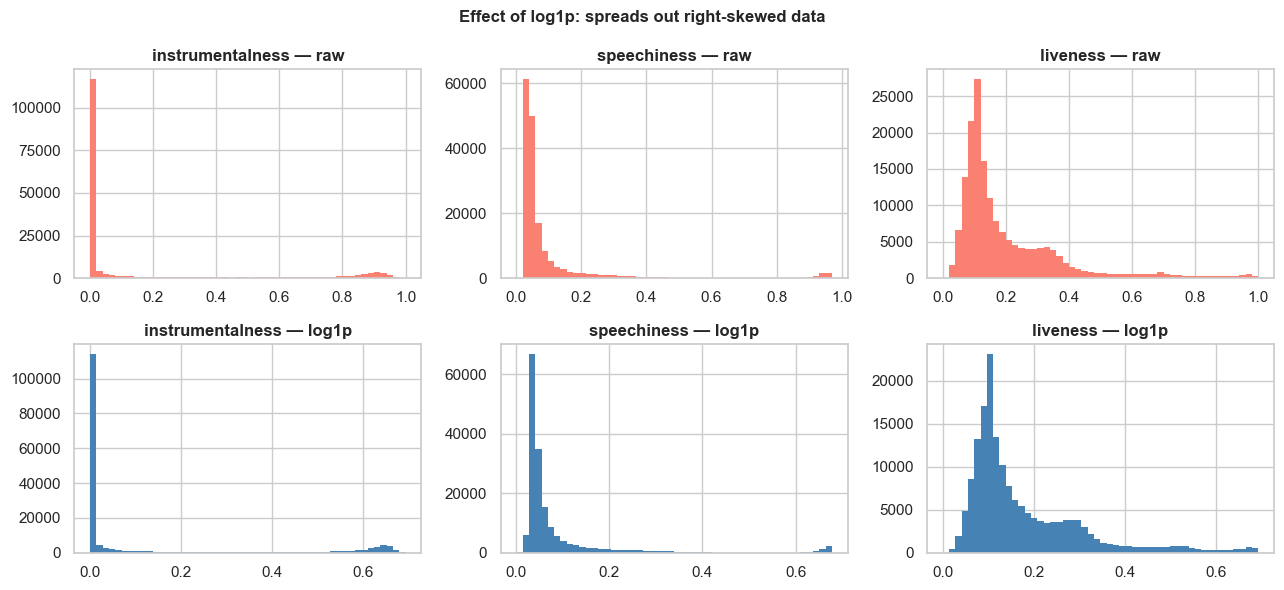

instrumentalness: skew 1.66 -> 1.56
speechiness: skew 4.08 -> 3.62
liveness: skew 2.16 -> 1.75


In [14]:
SKEWED = ['instrumentalness', 'speechiness', 'liveness']

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for i, feat in enumerate(SKEWED):
    axes[0, i].hist(df[feat], bins=50, color='salmon', edgecolor='none')
    axes[0, i].set_title(f'{feat} — raw', fontweight='bold')
    axes[1, i].hist(np.log1p(df[feat]), bins=50, color='steelblue', edgecolor='none')
    axes[1, i].set_title(f'{feat} — log1p', fontweight='bold')
plt.suptitle('Effect of log1p: spreads out right-skewed data', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

for feat in SKEWED:
    before = df[feat].skew()
    after  = np.log1p(df[feat]).skew()
    print(f'{feat}: skew {before:.2f} -> {after:.2f}')

## 5. Step 2 — Scale All Features to 0–1

MinMaxScaler maps each feature to the 0–1 range so no single feature dominates cosine similarity because of a larger raw value range.

In [15]:
MINMAX_COLS = ['valence', 'acousticness', 'danceability', 'energy', 'loudness']

mm = MinMaxScaler()
mm.fit(df[MINMAX_COLS])
print('MinMax ranges before scaling:')
for col in MINMAX_COLS:
    print(f'  {col:<18} [{df[col].min():.3f}, {df[col].max():.3f}]')
print()
print('After scaling: all columns in [0, 1]')

MinMax ranges before scaling:
  valence            [0.000, 1.000]
  acousticness       [0.000, 0.996]
  danceability       [0.000, 0.988]
  energy             [0.000, 1.000]
  loudness           [-60.000, 3.855]

After scaling: all columns in [0, 1]


## 6. Step 3 — Cyclic Encoding for Key

Musical keys are circular: after B (11) comes C (0). The raw number would make B and C look far apart (11 vs 0).
Sin/cos encoding places keys on a circle so adjacent keys are always close.

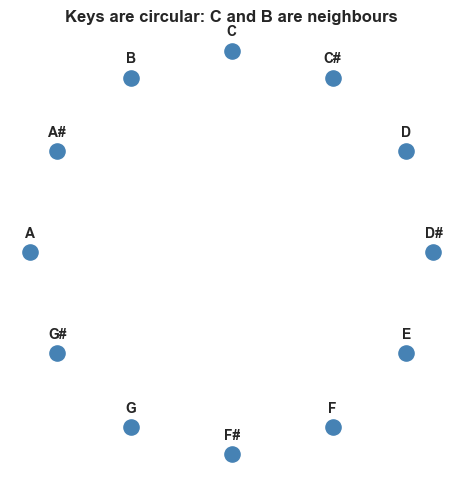

In [16]:
key_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
angles = [2 * np.pi * k / 12 for k in range(12)]
kx = np.sin(angles)
ky = np.cos(angles)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(kx, ky, s=120, color='steelblue', zorder=3)
for label, x, y in zip(key_labels, kx, ky):
    ax.annotate(label, (x, y), fontsize=10, ha='center', va='bottom',
                fontweight='bold', xytext=(0, 8), textcoords='offset points')
ax.set_title('Keys are circular: C and B are neighbours', fontweight='bold')
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

## 7. Step 4 — Binary Features

In [17]:
print('explicit values:', df['explicit'].value_counts().to_dict())
print('mode values    :', df['mode'].value_counts().to_dict())
print()
print('explicit -> int (0/1), popularity -> MinMax (0-1)')

explicit values: {False: 154668, True: 14372}
mode values    : {1: 119508, 0: 49532}

explicit -> int (0/1), popularity -> MinMax (0-1)


## 8. Assemble Feature Matrix

`build_feature_matrix()` from `src.features.build_features` runs all steps above
(log1p, MinMax, z-score+MinMax, cyclic key, binary cast) in a single call.

In [18]:
feature_matrix, feat_cols = build_feature_matrix(df)   # src function

track_index = df[['id', 'name', 'artists_clean', 'year', 'popularity']].copy()
track_index = track_index.rename(columns={'artists_clean': 'artists'})

print(f'Feature matrix : {feature_matrix.shape}  ({len(feat_cols)} features per track)')
print(f'Track index    : {track_index.shape}')
print(f'Feature names  : {feat_cols}')
print()

nan_count = feature_matrix.isnull().sum().sum()
inf_count = np.isinf(feature_matrix.values).sum()
val_min   = feature_matrix.drop(columns=['key_sin', 'key_cos']).min().min()
val_max   = feature_matrix.max().max()
print(f'NaN values: {nan_count}  (should be 0)')
print(f'Inf values: {inf_count}  (should be 0)')
print(f'Value range (excl. key sin/cos): [{val_min:.4f}, {val_max:.4f}]  (should be [0, 1])')

Feature matrix : (169040, 14)  (14 features per track)
Track index    : (169040, 5)
Feature names  : ['valence', 'acousticness', 'danceability', 'energy', 'loudness', 'log_instrumentalness', 'log_speechiness', 'log_liveness', 'tempo_norm', 'key_sin', 'key_cos', 'mode', 'explicit_int', 'popularity_norm']

NaN values: 0  (should be 0)
Inf values: 0  (should be 0)
Value range (excl. key sin/cos): [0.0000, 1.0000]  (should be [0, 1])


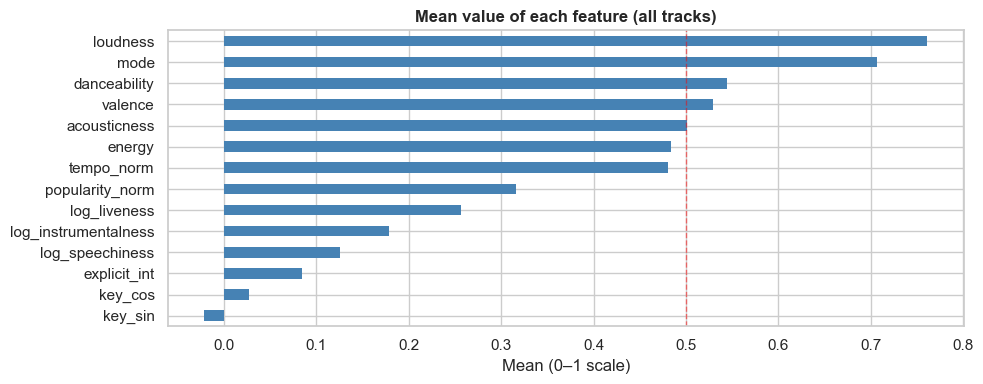

In [19]:
means = feature_matrix.mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 4))
means.plot(kind='barh', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Mean value of each feature (all tracks)', fontweight='bold')
ax.set_xlabel('Mean (0–1 scale)')
ax.axvline(0.5, color='red', linewidth=1, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Save Outputs

In [20]:
feature_matrix.to_csv(OUTPUT_DIR / 'feature_matrix.csv', index=False)
track_index.to_csv(OUTPUT_DIR / 'track_index.csv', index=False)

with open(OUTPUT_DIR / 'feature_columns.json', 'w') as f:
    json.dump(feat_cols, f, indent=2)

print('Saved:')
print(f'  feature_matrix.csv   {feature_matrix.shape}')
print(f'  track_index.csv      {track_index.shape}')
print(f'  feature_columns.json {len(feat_cols)} features')

Saved:
  feature_matrix.csv   (169040, 14)
  track_index.csv      (169040, 5)
  feature_columns.json 14 features


## 10. Summary

The feature vector has **14 dimensions**. Every value is in [−1, 1] — most are in [0, 1], only `key_sin` and `key_cos` can be negative.

| Group | Features | Transform |
|---|---|---|
| Audio (continuous) | valence, acousticness, danceability, energy, loudness | MinMax |
| Audio (skewed) | instrumentalness, speechiness, liveness | log1p + MinMax |
| Tempo | tempo_norm | z-score + MinMax |
| Key | key_sin, key_cos | Cyclic sin/cos |
| Binary | mode, explicit_int | 0 / 1 |
| Popularity | popularity_norm | MinMax |

**Next:** `05_content_based_recommender.ipynb`